# Лекція 3: Нейронні мережі як моделі


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 3  
**Тема лекції:** Нейронні мережі як моделі

## Цілі лекції

- Зрозуміти мотивацію переходу від лінійних моделей до нейронних мереж
- Ознайомитись із перцептроном як первісною моделлю нейрона
- Розуміти нейрони як параметризовані функції
- Засвоїти роль нелінійних функцій активації та їхні похідні
- Вивчити архітектуру неглибоких і глибоких нейронних мереж
- Розуміти пряме поширення (forward pass) та функцію втрат
- Засвоїти принцип зворотного поширення помилки (backpropagation)
- Застосувати `MLPClassifier` зі sklearn для практичних задач класифікації

## Передумови

- Знання логістичної регресії та градієнтного спуску (Тижні 1–2)
- Базові знання лінійної алгебри (множення матриць, транспонування)
- Знання основ математичного аналізу (похідні, правило ланцюга)
- Базове розуміння концепцій машинного навчання та ERM

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42


In [2]:
# ── Shared helper ────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, title='', ax=None, cmap='bwr'):
    ax = ax or plt.gca()
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap,
               edgecolors='k', s=30, linewidths=0.5)
    acc = (model.predict(X) == y).mean()
    ax.set_title(f'{title}\nacc={acc:.2f}')
    ax.set_xticks([]); ax.set_yticks([])

---
## 1. Мотивація: коли лінійні моделі не працюють

Логістична регресія знаходить **гіперплощину**, яка розділяє два класи. Це працює ідеально, коли класи є лінійно відокремлюваними, але реальні дані рідко бувають настільки впорядкованими.

Розглянемо три набори даних - один, з яким перцептрон впорається, і два, з якими він не зможе впоратися.

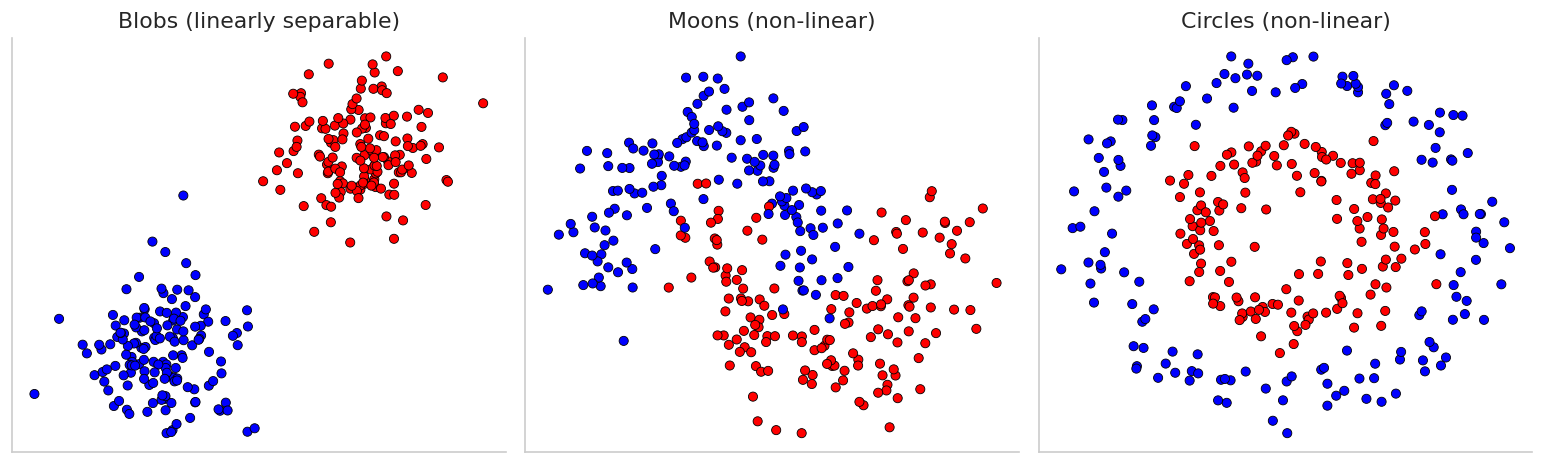

In [16]:
# Linearly separable: two blobs that are well-separated
X_blobs, y_blobs = make_blobs(n_samples=300, centers=[[-2, -2], [2, 2]],
                               cluster_std=0.8, random_state=SEED)
y_blobs = (y_blobs == 1).astype(int)

# Non-linearly separable
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=SEED)
X_circles, y_circles = make_circles(n_samples=300, noise=0.1,
                                    factor=0.5, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
datasets = [(X_blobs, y_blobs, 'Blobs (linearly separable)'),
            (X_moons, y_moons, 'Moons (non-linear)'),
            (X_circles, y_circles, 'Circles (non-linear)')]
for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolors='k', s=30, linewidths=0.5)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Пряма лінія може чітко розділити дані з датасету «blobs». Жодна пряма не може розділити «moons» або «circles» - нам потрібні криві, а це означає, що нам потрібна **нелінійність**.

---
## 2. Перцептрон

**Перцептрон** (Rosenblatt, 1958) - історичний предок нейронних мереж. Це безпосередня модель біологічного нейрона: багато зважених входів надходять до суматора, і якщо сумарний «сигнал» перевищує поріг, нейрон активується.

### 2.1 Структура

Нехай $\mathbf{x} \in \mathbb{R}^d$ - вхідний вектор. Перцептрон обчислює:

$$\hat{y} = \text{step}\!\left(\underbrace{\mathbf{w}^\top \mathbf{x} + b}_{z}\right), \qquad
\text{step}(z) = \begin{cases} 1 & z \geq 0 \\ 0 & z < 0 \end{cases}$$

- $\mathbf{w}$: вектор ваг (визначає важливість кожної ознаки)
- $b$: зсув (bias), який зміщує поріг прийняття рішення
- $z = \mathbf{w}^\top \mathbf{x} + b$: **передактивація** (pre-activation) або логіт; лінійна частина

### 2.2 Правило навчання

Ваги оновлюються лише для неправильно класифікованих прикладів:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat{y})\,\mathbf{x}, \qquad 
b \leftarrow b + \eta\,(y - \hat{y})$$

- Якщо передбачення правильне ($y = \hat{y}$): змін немає.
- Якщо передбачено 0, але істинне значення 1: $\mathbf{w}$ зміщується у напрямку $\mathbf{x}$.
- Якщо передбачено 1, але істинне значення 0: $\mathbf{w}$ зміщується у протилежному напрямку від $\mathbf{x}$.

**Гарантія збіжності:** якщо дані лінійно відокремлювані, теорема про збіжність перцептрона гарантує збіжність за скінченну кількість кроків. В іншому випадку алгоритм може ніколи не зійтися.

### 2.3 Основне обмеження

Функція step має **нульову похідну** майже всюди → неможливо застосувати градієнтний спуск для її навчання. Крім того, один перцептрон може навчитися лише **лінійним** межам прийняття рішення. Відомий приклад невдачі: він не може реалізувати функцію XOR.

In [4]:
class Perceptron:
    """Perceptron classifier trained with the Rosenblatt learning rule."""
    def __init__(self, lr=0.1, n_epochs=100):
        self.lr = lr
        self.n_epochs = n_epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        for _ in range(self.n_epochs):
            for xi, yi in zip(X, y):
                y_hat = int(np.dot(self.w, xi) + self.b >= 0)
                delta = self.lr * (yi - y_hat)
                self.w += delta * xi
                self.b += delta

    def predict(self, X):
        return (X @ self.w + self.b >= 0).astype(int)

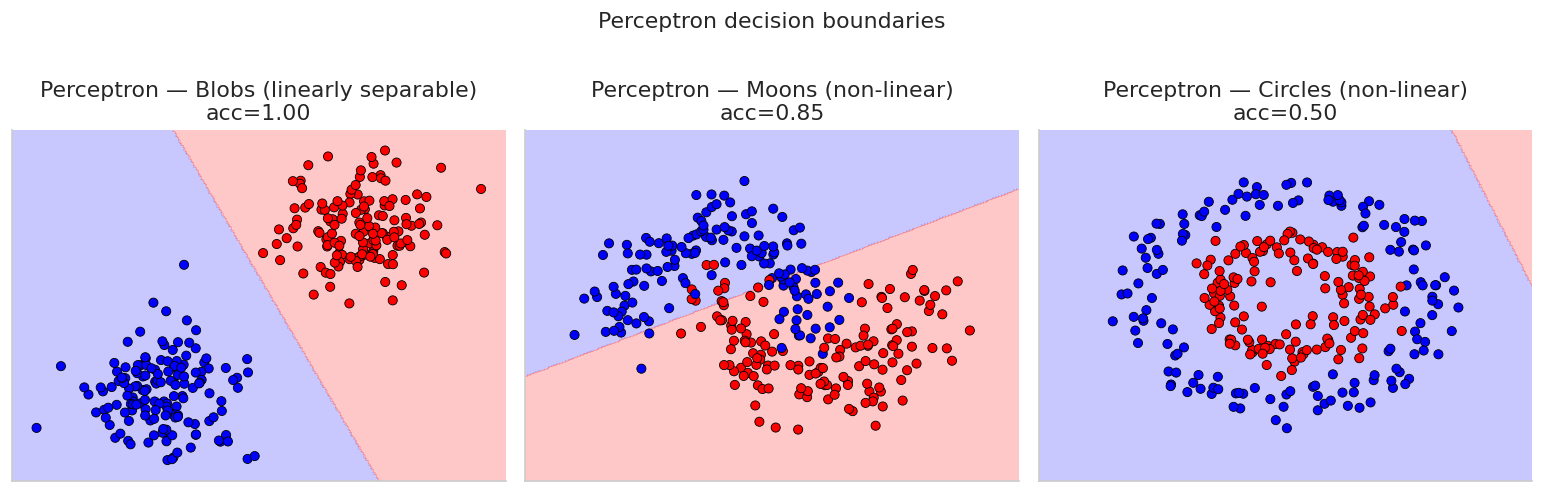

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (X, y, title) in zip(axes, datasets):
    p = Perceptron(lr=0.1, n_epochs=100)
    p.fit(X, y)
    plot_decision_boundary(p, X, y, title=f'Perceptron - {title}', ax=ax)
plt.suptitle('Perceptron decision boundaries', y=1.02)
plt.tight_layout()
plt.show()

**Спостереження:**
- **Blobs**: перцептрон знаходить чітку розділяючу пряму → майже ідеальна точність.
- **Moons / Circles**: незалежно від тривалості навчання межа залишається лінійною - модель принципово не здатна апроксимувати такі форми.

---
## 3. Нейрони як параметризовані функції

Сучасний **штучний нейрон** замінює step-функцію на гладку, диференційовну **функцію активації** $\sigma$:

$$a = \sigma(z), \qquad z = \mathbf{w}^\top \mathbf{x} + b$$

Можна розглядати нейрон як невелику параметризовану функцію:

$$f_{\mathbf{w},b}: \mathbf{x} \mapsto \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

Параметри $\mathbf{w}$ і $b$ навчаються з даних. Вибір $\sigma$ визначає *форму* виходу - чи є він обмеженим, монотонним або чи може набувати від’ємних значень. Багато нейронів, організованих у шари, утворюють **нейронну мережу**.

---
## 4. Чому необхідні нелінійні активації

Можна запитати: чому б просто не складати лінійні перетворення?

**Твердження:** композиція лінійних функцій є лінійною.

**Доведення:** нехай маємо два шари без функції активації:

$$\mathbf{h} = W^{[1]}\mathbf{x} + \mathbf{b}^{[1]}$$
$$\hat{\mathbf{y}} = W^{[2]}\mathbf{h} + \mathbf{b}^{[2]}$$

Підставляючи:

$$\hat{\mathbf{y}} = W^{[2]}\!\left(W^{[1]}\mathbf{x} + \mathbf{b}^{[1]}\right) + \mathbf{b}^{[2]}
= \underbrace{W^{[2]}W^{[1]}}_{W^*}\mathbf{x} + \underbrace{W^{[2]}\mathbf{b}^{[1]} + \mathbf{b}^{[2]}}_{\mathbf{b}^*}$$

Це лише *одне* лінійне перетворення $\hat{\mathbf{y}} = W^*\mathbf{x} + \mathbf{b}^*$. **Незалежно від кількості шарів, без нелінійності мережа зводиться до логістичної регресії.**

Нелінійні активації руйнують цю редукцію - вони роблять простір функцій **строго багатшим** із кожним додатковим шаром.

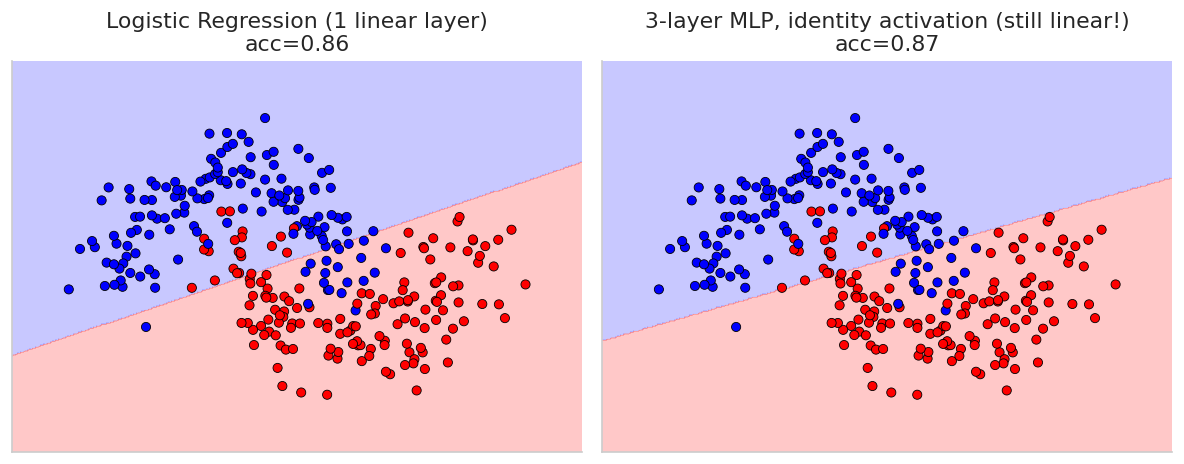

In [6]:
# Demonstration: "deep" linear network vs. 1-layer logistic regression
# Both should produce the same linear boundary
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lr_model = LogisticRegression()
lr_model.fit(X_moons, y_moons)
plot_decision_boundary(lr_model, X_moons, y_moons,
                       title='Logistic Regression (1 linear layer)', ax=axes[0])

# MLP with identity activation = still linear
mlp_linear = MLPClassifier(hidden_layer_sizes=(64, 64),
                            activation='identity',  # f(x) = x
                            max_iter=1000, random_state=SEED)
mlp_linear.fit(X_moons, y_moons)
plot_decision_boundary(mlp_linear, X_moons, y_moons,
                       title='3-layer MLP, identity activation (still linear!)', ax=axes[1])

plt.tight_layout()
plt.show()

Навіть 3-шарова мережа з лінійними (тотожними) активаціями формує ту саму лінійну межу, що й логістична регресія - що підтверджує теорію.

---
## 5. Функції активації

### 5.1 Огляд і мотивація

| Функція | Формула | Чому використовуємо |
|----------|---------|------------|
| **Sigmoid** | $\dfrac{1}{1+e^{-z}}$ | Вихід у $(0,1)$; природна інтерпретація ймовірності; використовується у вихідному шарі для бінарної класифікації |
| **Tanh** | $\dfrac{e^z - e^{-z}}{e^z + e^{-z}}$ | Центрована відносно нуля (на відміну від sigmoid); більші градієнти; часто краща за sigmoid у прихованих шарах |
| **ReLU** | $\max(0, z)$ | Проста, швидка, не насичується при $z>0$; стандартний вибір для прихованих шарів у сучасних мережах |
| **Leaky ReLU** | $\max(\alpha z,\, z)$, $\alpha\!\ll\!1$ | Усунення проблеми «мертвих ReLU»: нейрони з $z<0$ завжди повертають 0 і перестають навчатися |

### 5.2 Проблема зникаючого градієнта (анонс)

Sigmoid і tanh **насичуються**: для великих $|z|$ їхня похідна прямує до нуля. У глибоких мережах градієнти перемножуються шар за шаром під час зворотнього ходу нейронної мережі - багато майже нульових множників призводять до того, що градієнт у ранніх шарах стає вкрай малим, і навчання сповільнюється або зупиняється. ReLU уникає цього для додатних значень входу.

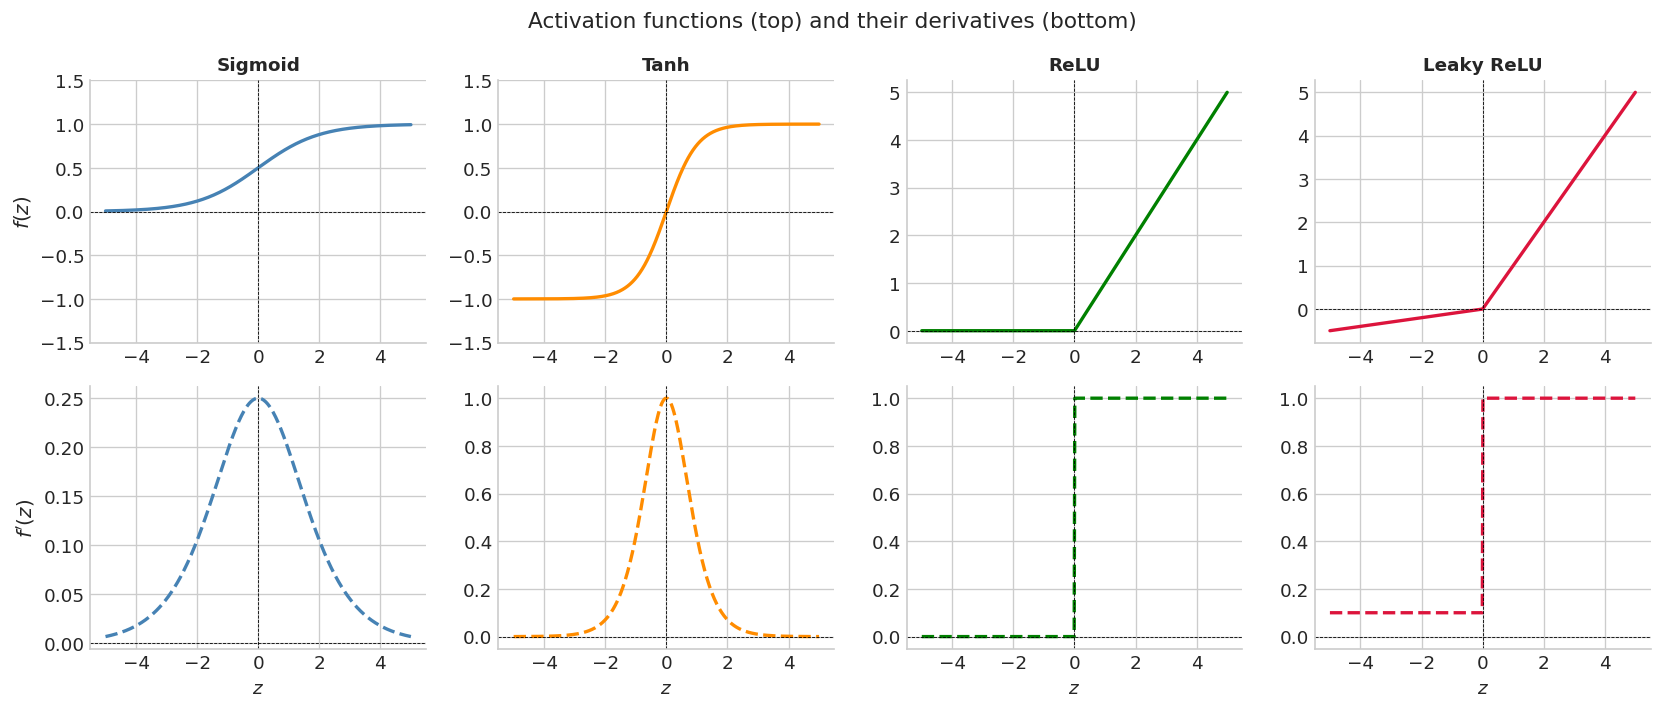

In [7]:
z = np.linspace(-5, 5, 500)

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def d_sigmoid(z):    s = sigmoid(z); return s * (1 - s)
def d_tanh(z):       return 1 - np.tanh(z)**2
def relu(z):         return np.maximum(0, z)
def d_relu(z):       return (z > 0).astype(float)
def leaky_relu(z, a=0.1):   return np.where(z >= 0, z, a * z)
def d_leaky_relu(z, a=0.1): return np.where(z >= 0, 1.0, a)

fns = [
    ('Sigmoid',      sigmoid(z),            d_sigmoid(z),         'steelblue'),
    ('Tanh',         np.tanh(z),            d_tanh(z),            'darkorange'),
    ('ReLU',         relu(z),               d_relu(z),            'green'),
    ('Leaky ReLU',   leaky_relu(z),         d_leaky_relu(z),      'crimson'),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for col, (name, f, df, color) in enumerate(fns):
    # Function
    ax = axes[0, col]
    ax.plot(z, f, color=color, lw=2)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('$f(z)$' if col == 0 else '')
    ax.set_ylim(-1.5, 1.5) if name in ('Sigmoid', 'Tanh') else None

    # Derivative
    ax2 = axes[1, col]
    ax2.plot(z, df, color=color, lw=2, ls='--')
    ax2.axhline(0, color='k', lw=0.5, ls='--')
    ax2.axvline(0, color='k', lw=0.5, ls='--')
    ax2.set_ylabel("$f'(z)$" if col == 0 else '')
    ax2.set_xlabel('$z$')

axes[0, 0].set_ylabel('$f(z)$', fontsize=12)
axes[1, 0].set_ylabel("$f'(z)$", fontsize=12)
fig.suptitle('Activation functions (top) and their derivatives (bottom)', fontsize=13)
plt.tight_layout()
plt.show()

**Спостереження з графіків похідних:**
- **Sigmoid / Tanh**: похідні максимальні поблизу 0 і спадають до нуля при великих $|z|$ → насичення → зникаючі градієнти в глибоких мережах.
- **ReLU**: похідна дорівнює 1 для $z > 0$ → немає насичення з додатного боку. Але 0 для $z \leq 0$ → «мертві нейрони».
- **Leaky ReLU**: похідна мала, але ненульова ($\alpha = 0.1$) для $z < 0$ → усуває проблему мертвих нейронів.

### 5.3 Формули похідних

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

$$\tanh'(z) = 1 - \tanh^2(z)$$

$$\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

Ці формули є критично важливими - ви реалізуєте їх у лабораторній роботі під час зворотного поширення.

---
## 6. Архітектура мережі: неглибокі та глибокі

### 6.1 Нотація шарів

Ми об'єднуємо нейрони у **шари**. Усі нейрони одного шару отримують однаковий вхід і обчислюють виходи паралельно.

Для мережі з $L$ шарами (вхід - шар 0):

$$\mathbf{a}^{[0]} = \mathbf{x} \qquad \text{(вхід)}$$

Для $l = 1, \ldots, L$:
$$\mathbf{z}^{[l]} = W^{[l]}\,\mathbf{a}^{[l-1]} + \mathbf{b}^{[l]} \qquad \text{(передактивація)}$$
$$\mathbf{a}^{[l]} = \sigma^{[l]}\!\left(\mathbf{z}^{[l]}\right) \qquad \text{(активація)}$$

$$\hat{\mathbf{y}} = \mathbf{a}^{[L]} \qquad \text{(вихід)}$$

Розміри: $W^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}$, $\mathbf{b}^{[l]} \in \mathbb{R}^{n_l}$, де $n_l$ - кількість нейронів у шарі $l$.

### 6.2 Неглибокі та глибокі мережі

| | Неглибока НМ | Глибока НМ |
|-|-----------|--------|
| Приховані шари | 1 | 2 або більше |
| Потрібна **ширина** | Потенційно експоненційна | Поліноміальна |
| Складність навчання | Простіше | Складніше (зникаючі градієнти тощо) |
| Навчання ознак | Обмежене | Ієрархічне (ребра → форми → об'єкти) |

> **Теорема універсальної апроксимації** (Cybenko, 1989; Hornik, 1991): один прихований шар із достатньою кількістю нейронів може апроксимувати будь-яку неперервну функцію на компактній множині з довільною точністю. Проте *глибина* часто експоненційно ефективніша за *ширину* - це головна мотивація глибокого навчання.

---
## 7. Теорія: пряме поширення, функція втрат і зворотне поширення

### 7.1 Пряме поширення (матрична форма)

Пряме поширення застосовує рівняння шарів зліва направо, зберігаючи $Z^{[l]}$ і $A^{[l]}$ на кожному кроці. Ці проміжні значення кешуються - вони знадобляться під час зворотного поширення.

Для батчу з $N$ прикладів усі операції є **матричними**:

| Символ | Розмір | Опис |
|--------|--------|------|
| $X = A^{[0]}$ | $N \times d_0$ | вхідна матриця (кожен рядок - один приклад) |
| $W^{[l]}$ | $n_l \times n_{l-1}$ | матриця ваг шару $l$ |
| $\mathbf{b}^{[l]}$ | $n_l$ | вектор зсувів шару $l$ |
| $Z^{[l]},\; A^{[l]}$ | $N \times n_l$ | передактивації та активації всього батчу |

Для $l = 1, \ldots, L$:

$$Z^{[l]} = A^{[l-1]}\,W^{[l]\top} + \mathbf{b}^{[l]\top} \in \mathbb{R}^{N \times n_l}$$

$$A^{[l]} = \sigma^{[l]}\!\left(Z^{[l]}\right) \in \mathbb{R}^{N \times n_l}$$

$$\hat{Y} = A^{[L]} \in \mathbb{R}^{N \times n_L}$$

Множення $A^{[l-1]} W^{[l]\top}$ застосовує ваги одночасно до всіх $N$ прикладів; зсув $\mathbf{b}^{[l]\top}$ додається broadcasting'ом по рядках.

### 7.2 Функція втрат

Для **бінарної класифікації** (вихідний шар: sigmoid, $\hat{y} \in (0,1)$) використовуємо **бінарну крос-ентропію**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

Інтуїція: сильно штрафує впевнені неправильні передбачення (логарифм прямує до $-\infty$); винагороджує впевнені правильні (log 1 = 0).

### 7.3 Зворотне поширення (матрична форма)

Зворотне поширення - це **систематичне застосування правила ланцюга** від вихідного шару до вхідного.

Матриця похибок $\Delta^{[l]} \in \mathbb{R}^{N \times n_l}$ містить $\dfrac{\partial \mathcal{L}}{\partial Z^{[l]}}$ для всього батчу одночасно.

Потрібно обчислити $\dfrac{\partial \mathcal{L}}{\partial W^{[l]}}$ і $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}}$ для кожного шару $l$.

**Крок 1 - похибка вихідного шару** (для sigmoid + BCE відбувається красиве спрощення):

$$\Delta^{[L]} = A^{[L]} - Y \in \mathbb{R}^{N \times n_L}$$

**Крок 2 - похибки прихованих шарів** (поширення назад):

$$\Delta^{[l]} = \left(\Delta^{[l+1]}\,W^{[l+1]}\right) \odot \sigma'^{[l]}\!\left(Z^{[l]}\right) \in \mathbb{R}^{N \times n_l}$$

де $\odot$ - поелементне множення; $\Delta^{[l+1]} \in \mathbb{R}^{N \times n_{l+1}}$, $W^{[l+1]} \in \mathbb{R}^{n_{l+1} \times n_l}$.

**Крок 3 - градієнти параметрів:**

$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{N}\,\Delta^{[l]\top}\, A^{[l-1]} \in \mathbb{R}^{n_l \times n_{l-1}}, \qquad
  \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}} = \frac{1}{N}\,\mathbf{1}_N^\top\,\Delta^{[l]} \in \mathbb{R}^{n_l}$$

**Крок 4 - оновлення методом градієнтного спуску:**

$$W^{[l]} \leftarrow W^{[l]} - \eta\,\frac{\partial \mathcal{L}}{\partial W^{[l]}}, \qquad
  \mathbf{b}^{[l]} \leftarrow \mathbf{b}^{[l]} - \eta\,\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}}$$

**У лабораторній роботі ви реалізуєте Кроки 1–4 з нуля.**

Поки що використаємо `MLPClassifier` зі scikit-learn, щоб дослідити, як виглядає навчена мережа.

---
## 8. Експерименти з `MLPClassifier`

### 8.1 Базовий приклад: до та після навчання

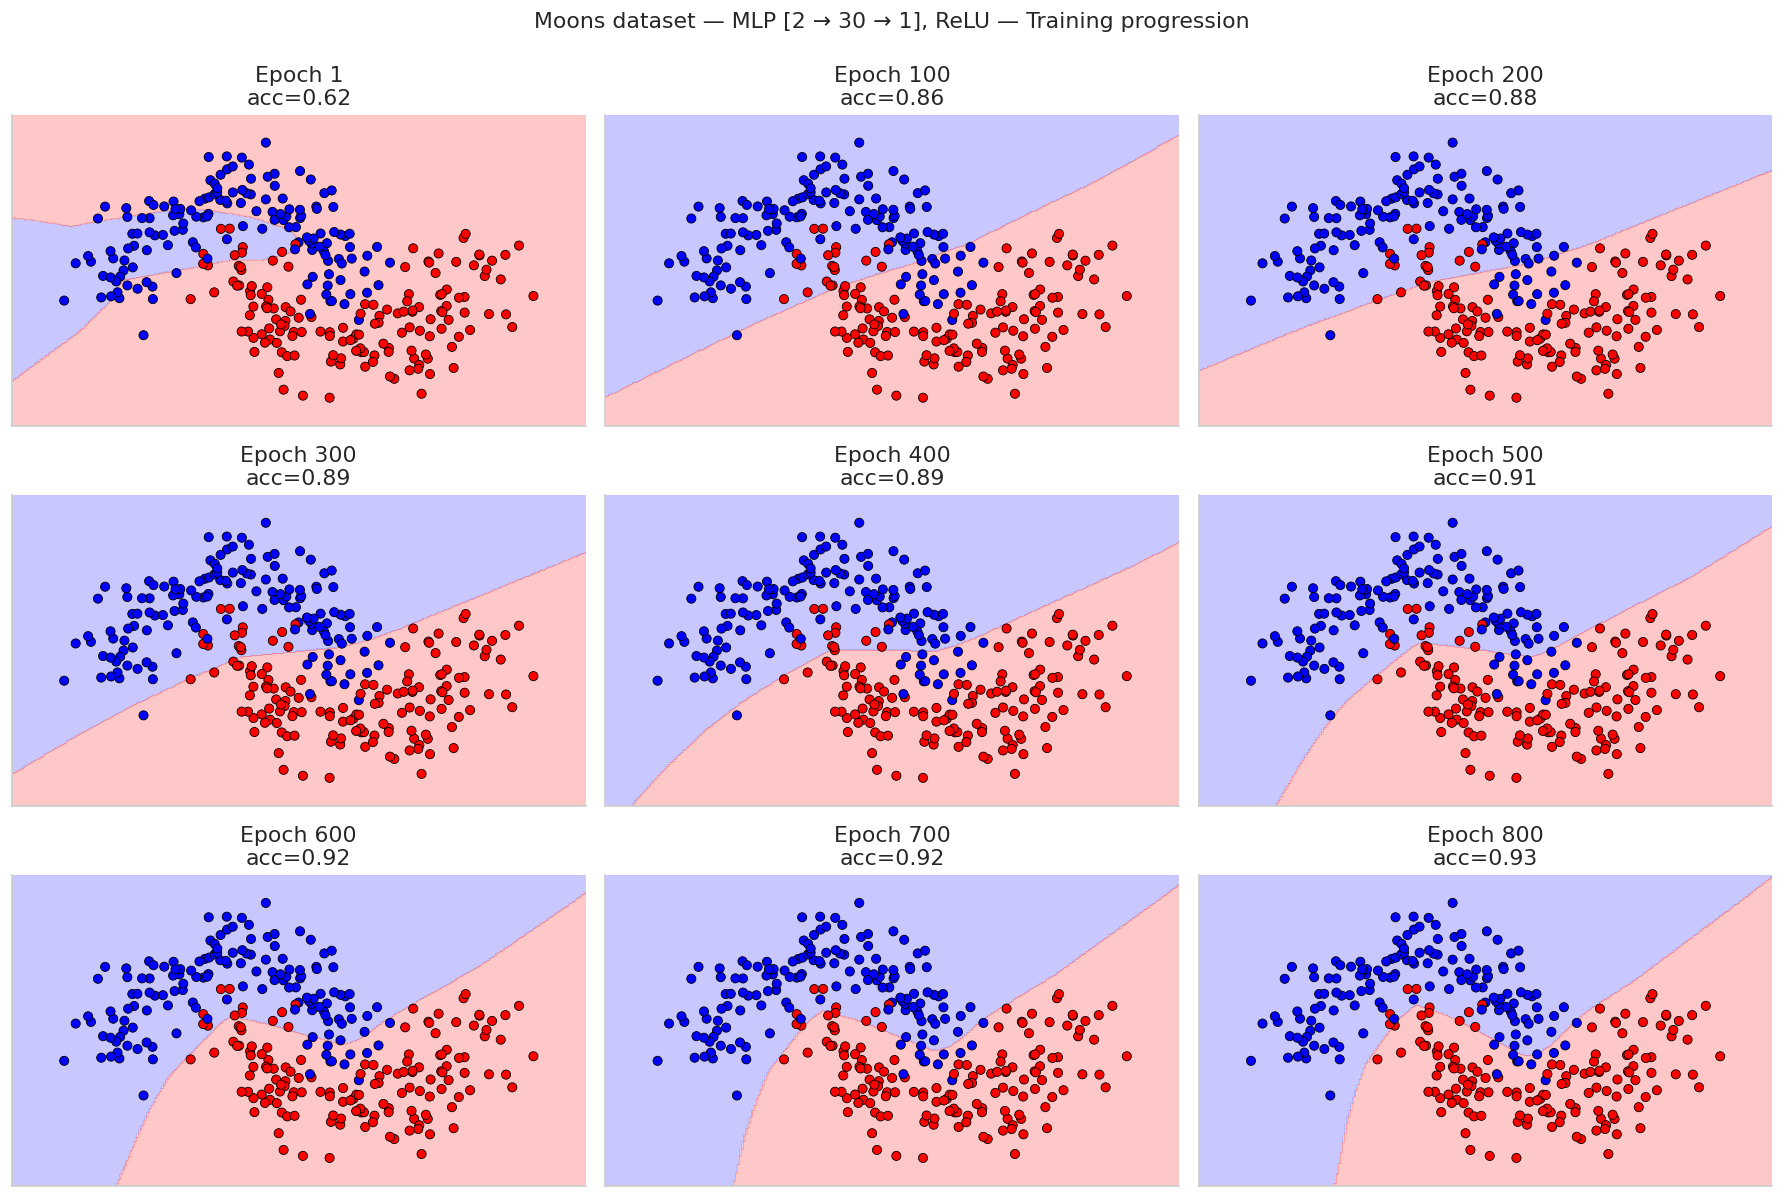

In [8]:
# Scaler normalises data to mean=0, std=1 – good practice before training NNs
scaler = StandardScaler()
X_m = scaler.fit_transform(X_moons)

# Train models at different epochs: 1, 100, 200, 300, 400, 500, 600, 700, 800
epochs = [1, 100, 200, 300, 400, 500, 600, 700, 800]
models = []
for epoch in epochs:
    mlp = MLPClassifier(hidden_layer_sizes=(30,), activation='relu',
                        max_iter=epoch, random_state=SEED)
    mlp.fit(X_m, y_moons)
    models.append(mlp)

# Create 2x3 grid to visualize all epochs
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, epoch, model in zip(axes, epochs, models):
    plot_decision_boundary(model, X_m, y_moons,
                           title=f'Epoch {epoch}', ax=ax)

plt.suptitle('Moons dataset - MLP [2 → 30 → 1], ReLU - Training progression', y=0.995)
plt.tight_layout()
plt.show()

### 8.2 Вплив прихованих шарів

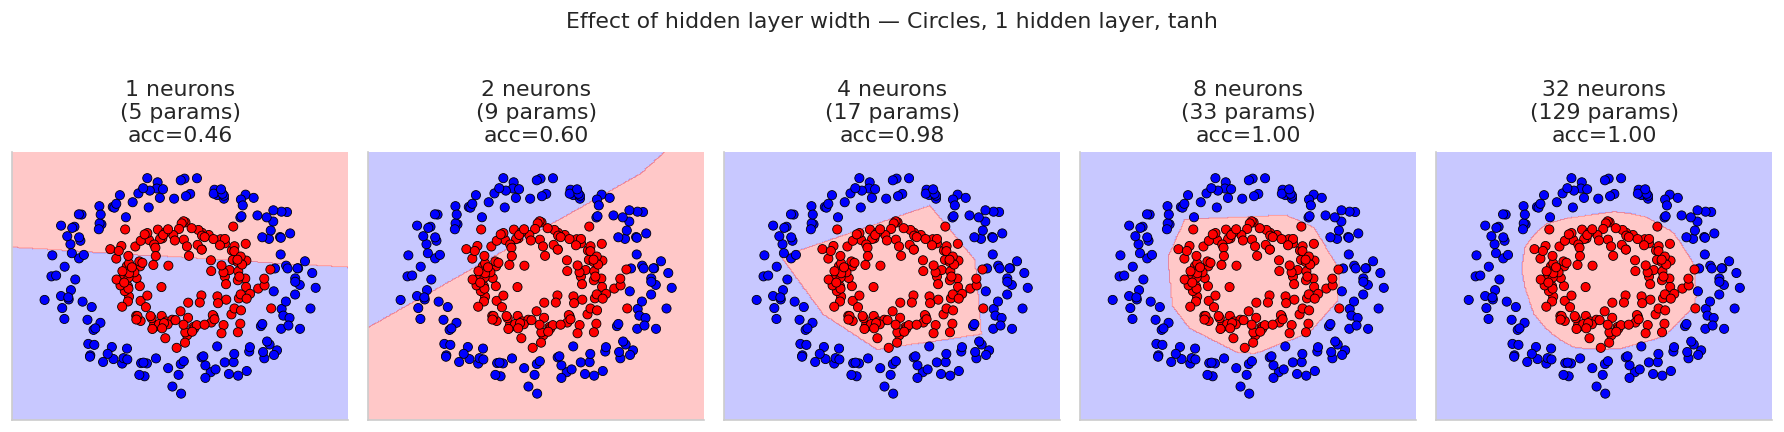

In [9]:
hidden_sizes = [1, 2, 4, 8, 32]
X_c = scaler.fit_transform(X_circles)

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(15, 3.5))
for ax, h in zip(axes, hidden_sizes):
    m = MLPClassifier(hidden_layer_sizes=(h,), activation='relu',
                      max_iter=1000, random_state=SEED)
    m.fit(X_c, y_circles)
    nparams = sum(w.size for w in m.coefs_) + sum(b.size for b in m.intercepts_)
    plot_decision_boundary(m, X_c, y_circles,
                           title=f'{h} neurons\n({nparams} params)', ax=ax)
plt.suptitle('Effect of hidden layer width - Circles, 1 hidden layer, tanh', y=1.02)
plt.tight_layout()
plt.show()

**Спостереження:** дуже мала кількість нейронів → недонавчання (underfitting); більша кількість нейронів → мережа має достатню ємність, щоб навчитися круговій межі розділення.

### 8.3 Вплив глибини мережі

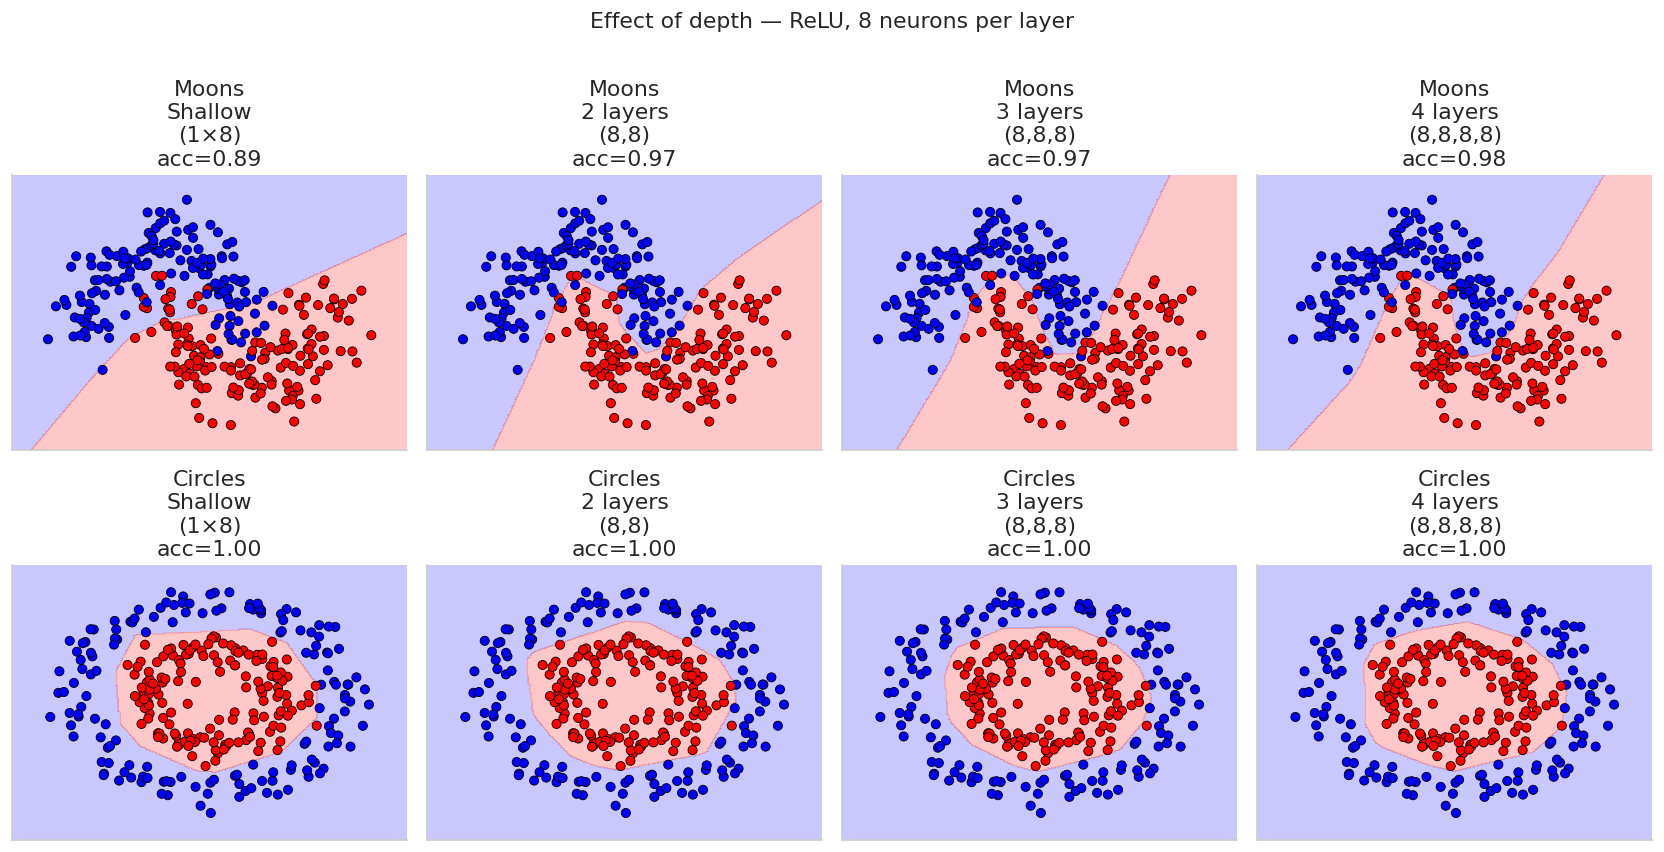

In [10]:
architectures = {
    'Shallow\n(1×8)':     (8,),
    '2 layers\n(8,8)':    (8, 8),
    '3 layers\n(8,8,8)':  (8, 8, 8),
    '4 layers\n(8,8,8,8)':(8, 8, 8, 8),
}

fig, axes = plt.subplots(2, len(architectures), figsize=(14, 7))
for col, (label, arch) in enumerate(architectures.items()):
    for row, (X, y, name) in enumerate([(X_m, y_moons, 'Moons'),
                                         (X_c, y_circles, 'Circles')]):
        m = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                          max_iter=2000, random_state=SEED)
        m.fit(X, y)
        plot_decision_boundary(m, X, y,
                               title=f'{name}\n{label}',
                               ax=axes[row, col])
plt.suptitle('Effect of depth - ReLU, 8 neurons per layer', y=1.01)
plt.tight_layout()
plt.show()

### 8.4 Вплив функції активації

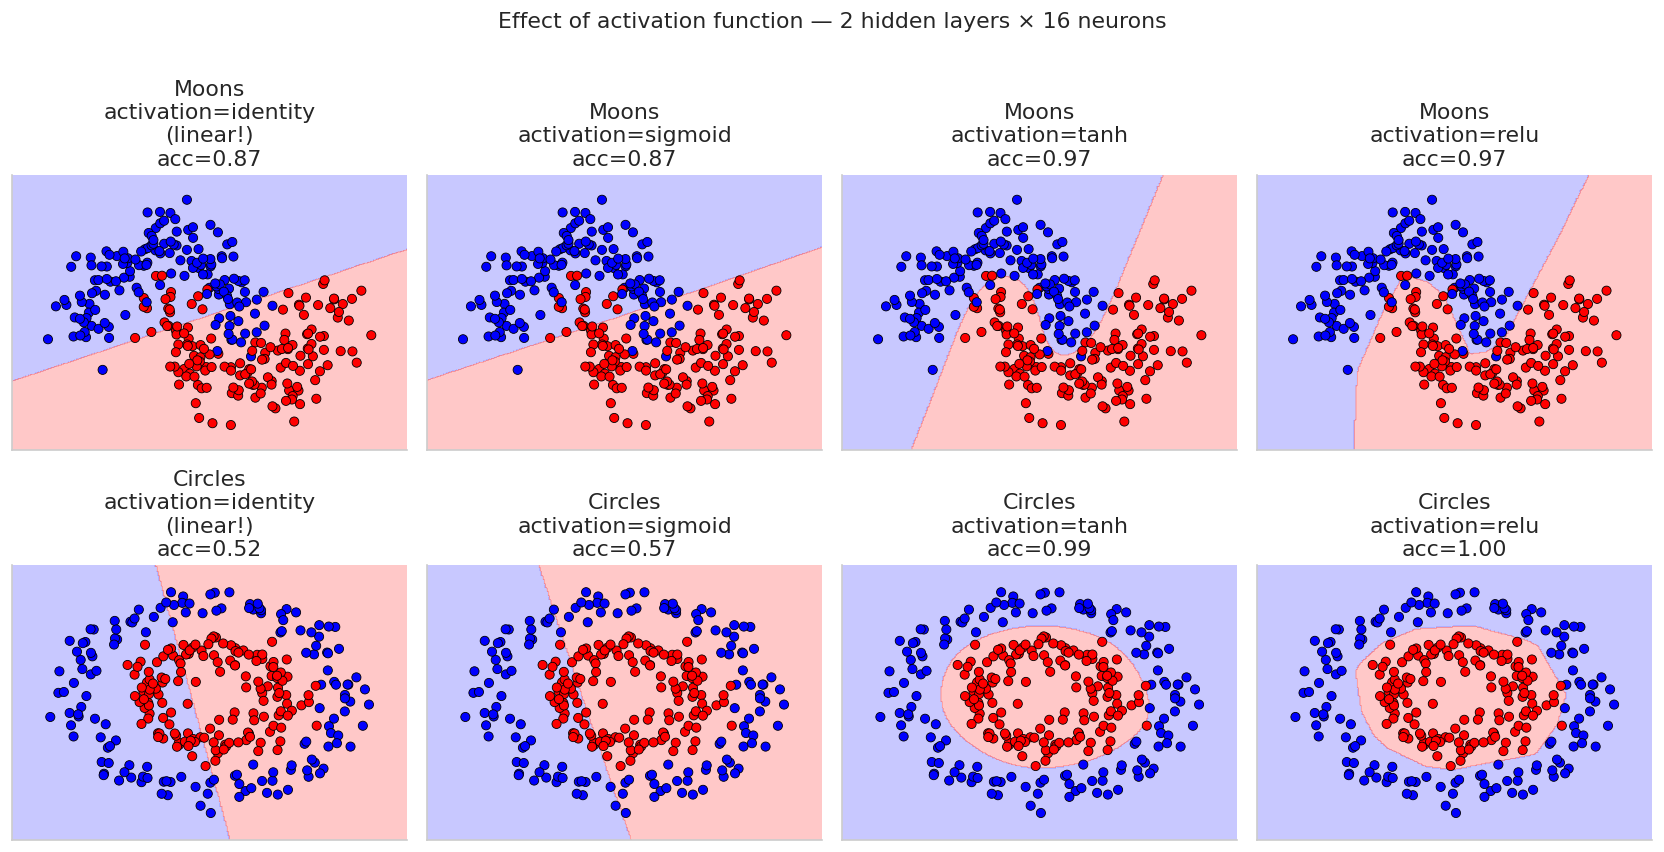

In [11]:
activations_sklearn = ['identity', 'logistic', 'tanh', 'relu']
labels = ['identity\n(linear!)', 'sigmoid', 'tanh', 'relu']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, (act, lbl) in enumerate(zip(activations_sklearn, labels)):
    for row, (X, y, name) in enumerate([(X_m, y_moons, 'Moons'),
                                         (X_c, y_circles, 'Circles')]):
        m = MLPClassifier(hidden_layer_sizes=(16, 16), activation=act,
                          max_iter=2000, random_state=SEED) # alpha=1e-6, learning_rate_init=0.1, hidden_layer_sizes=(16,)
        m.fit(X, y)
        plot_decision_boundary(m, X, y,
                               title=f'{name}\nactivation={lbl}',
                               ax=axes[row, col])
plt.suptitle('Effect of activation function - 2 hidden layers × 16 neurons', y=1.01)
plt.tight_layout()
plt.show()

**Спостереження:** тотожна (identity) активація → завжди лінійна модель. Sigmoid*/tanh/ReLU здатні навчатися нелінійних меж. Межі з ReLU є кусково-лінійними; sigmoid/tanh формують більш гладкі криві.

#### 8.4.1 Лінійний колапс у мережах із sigmoid

**Лінійний колапс** виникає тоді, коли глибока нейронна мережа з нелінійними активаціями поводиться приблизно як одне афінне перетворення. Розглянемо мережу з двома прихованими шарами:

$$
f(x) = W_3 \, \sigma(W_2 \, \sigma(W_1 x + b_1) + b_2) + b_3.
$$

Якщо нелінійності працюють у майже лінійному режимі, композиція зводиться до

$$
f(x) \approx \tilde{W}x + \tilde{b},
$$

тобто виразна здатність мережі зводиться до логістичної регресії.

Перший механізм - **локальна лінійність sigmoid**. Поблизу $z = 0$ розклад Тейлора дає

$$
\sigma(z) = \frac{1}{1+e^{-z}} \approx \tfrac{1}{2} + \tfrac{1}{4}z + \mathcal{O}(z^2).
$$

Якщо передактивації задовольняють умову $|z| \ll 1$, кожен прихований шар поводиться як

$$
\sigma(Wx + b) \approx a + Bx,
$$

тобто як афінне перетворення. Оскільки композиція афінних відображень знову є афінною,

$$
A_3(A_2(A_1 x + c_1) + c_2) + c_3 = \tilde{W}x + \tilde{b},
$$

вся мережа стає ефективно лінійною.

Другий чинник - **загасання градієнта**. Похідна sigmoid:

$$
\sigma'(z) = \sigma(z)(1-\sigma(z)) \le 0.25.
$$

Для двох прихованих шарів зворотно поширені градієнти містять добутки вигляду

$$
\delta \propto \sigma'(z_2)\sigma'(z_1),
$$

модуль яких обмежений $0.25^2 = 0.0625$. Тому оновлення ваг

$$
\Delta W \propto -\eta \, \nabla_W \mathcal{L}
$$

залишаються малими, не дозволяючи вагам перейти в суттєво нелінійний режим.

Третій фактор - **L2-регуляризація**, яка додає штраф

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \alpha \|W\|_2^2.
$$

Для потрапляння в сильно нелінійний режим потрібні великі ваги, але квадратичний штраф це стримує. Оптимізатор віддає перевагу розв’язкам з малою нормою, які залишаються поблизу $z \approx 0$, підсилюючи лінійну поведінку.

Нарешті, динаміка навчання створює **самостабілізуючу петлю**: малі початкові ваги ⇒ $z \approx 0$; майже лінійна поведінка $\sigma(z) \approx \tfrac{1}{2} + \tfrac{1}{4}z$; малі похідні ⇒ малі градієнти; малі градієнти ⇒ малі ваги. Формально,

$$
\|W_{t+1}\| \approx \|W_t - \eta \, \nabla_W \mathcal{L}\| \approx \|W_t\|,
$$

тому система залишається у лінійній «западині», якщо налаштування оптимізації або вибір функції активації не змінюють цю динаміку.

### 8.5 Вплив швидкості навчання

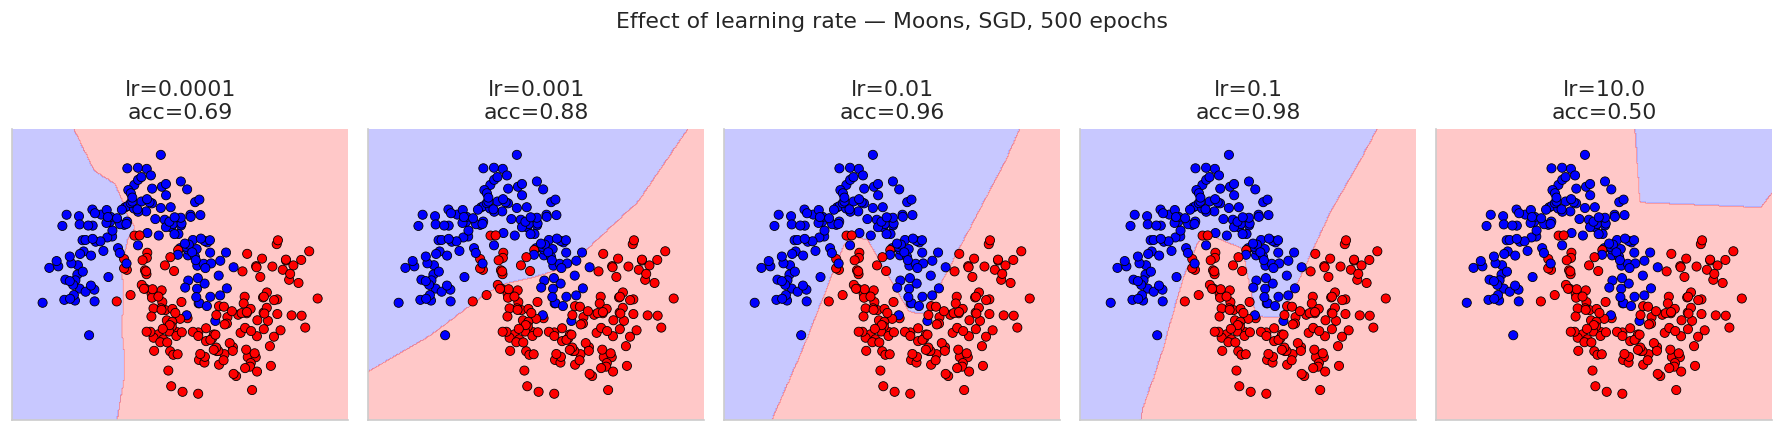

In [12]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 10.0]

fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 3.5))
for ax, lr in zip(axes, learning_rates):
    m = MLPClassifier(hidden_layer_sizes=(16, 16), activation='relu',
                      learning_rate_init=lr, solver='sgd',
                      max_iter=500, random_state=SEED)
    m.fit(X_m, y_moons)
    plot_decision_boundary(m, X_m, y_moons, title=f'lr={lr}', ax=ax)
plt.suptitle('Effect of learning rate - Moons, SGD, 500 epochs', y=1.02)
plt.tight_layout()
plt.show()

**Спостереження:**
- Занадто мала (наприклад, 0.0001): навчання повільне; модель ще не зійшлася.
- Оптимальний діапазон (0.001 – 0.01): збігається до хорошого розв’язку.
- Занадто велика (наприклад, 10.0): градієнтні кроки «перестрибують» мінімум; функція втрат може розходитись або коливатись → низька точність.

### 8.6 Крива навчання

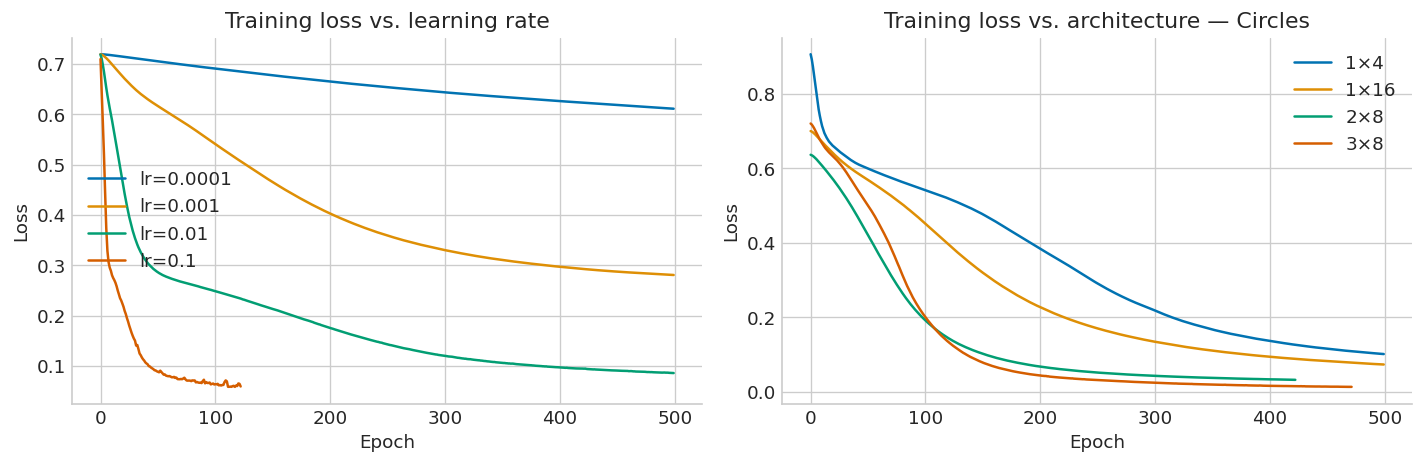

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves for different learning rates
ax = axes[0]
for lr in [0.0001, 0.001, 0.01, 0.1]:
    m = MLPClassifier(hidden_layer_sizes=(16, 16), activation='relu',
                      learning_rate_init=lr, solver='sgd',
                      max_iter=500, random_state=SEED)
    m.fit(X_m, y_moons)
    ax.plot(m.loss_curve_, label=f'lr={lr}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss vs. learning rate')
ax.legend()

# Loss curves for different architectures
ax2 = axes[1]
for arch, lbl in [((4,), '1×4'), ((16,), '1×16'),
                   ((8, 8), '2×8'), ((8, 8, 8), '3×8')]:
    m = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                      learning_rate_init=0.01, solver='sgd',
                      max_iter=500, random_state=SEED)
    m.fit(X_c, y_circles)
    ax2.plot(m.loss_curve_, label=lbl)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Training loss vs. architecture - Circles')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 9. Кількість параметрів

Розуміння ємності моделі є важливим. Ось як підрахувати кількість параметрів у повнозв’язній (fully-connected) мережі:

In [14]:
def count_params(layer_sizes):
    total = 0
    for i in range(1, len(layer_sizes)):
        w = layer_sizes[i] * layer_sizes[i-1]
        b = layer_sizes[i]
        print(f'  Layer {i}: W[{layer_sizes[i-1]}×{layer_sizes[i]}] '
              f'= {w} weights + {b} biases = {w+b}')
        total += w + b
    print(f'  ──────────────────────────────')
    print(f'  Total: {total} parameters')

print('2→8→1 (shallow, 8 neurons):')
count_params([2, 8, 1])
print()
print('2→8→8→1 (2 hidden layers):')
count_params([2, 8, 8, 1])
print()
print('2→8→8→8→1 (3 hidden layers):')
count_params([2, 8, 8, 8, 1])

2→8→1 (shallow, 8 neurons):
  Layer 1: W[2×8] = 16 weights + 8 biases = 24
  Layer 2: W[8×1] = 8 weights + 1 biases = 9
  ──────────────────────────────
  Total: 33 parameters

2→8→8→1 (2 hidden layers):
  Layer 1: W[2×8] = 16 weights + 8 biases = 24
  Layer 2: W[8×8] = 64 weights + 8 biases = 72
  Layer 3: W[8×1] = 8 weights + 1 biases = 9
  ──────────────────────────────
  Total: 105 parameters

2→8→8→8→1 (3 hidden layers):
  Layer 1: W[2×8] = 16 weights + 8 biases = 24
  Layer 2: W[8×8] = 64 weights + 8 biases = 72
  Layer 3: W[8×8] = 64 weights + 8 biases = 72
  Layer 4: W[8×1] = 8 weights + 1 biases = 9
  ──────────────────────────────
  Total: 177 parameters


---
## 10. Підсумок

| Поняття | Ключова ідея |
|---------|-------------|
| **Перцептрон** | Перший навчуваний нейрон; лише лінійна модель; недиференційовний |
| **Штучний нейрон** | Лінійна комбінація + гладка активація; диференційовний |
| **Навіщо нелінійність?** | Композиція лінійних відображень є лінійною; потрібна $\sigma$, щоб вийти за ці межі |
| **Sigmoid/Tanh** | Гладкі, обмежені; насичуються → зникаючі градієнти в глибоких мережах |
| **ReLU** | Проста, без насичення при $z>0$; стандартна активація прихованих шарів |
| **Пряме поширення** | $z^{[l]} = W^{[l]}a^{[l-1]} + b^{[l]}$, $a^{[l]} = \sigma(z^{[l]})$ |
| **Функція втрат** | Бінарна крос-ентропія для класифікації |
| **Зворотне поширення** | Правило ланцюга справа наліво; $\delta^{[l]}$ переносить сигнал помилки |
| **Глибина** | Більше шарів → ієрархічні ознаки; ефективніше за ширину |
| **Швидкість навчання** | Занадто мала → повільно; занадто велика → розходиться |

**У лабораторній роботі:** ви реалізуєте пряме поширення, бінарну крос-ентропію та зворотне поширення з нуля у NumPy, навчите двошарову мережу на наборах даних moons і circles, перевірите градієнти чисельною перевіркою та порівняєте результати з `MLPClassifier` зі sklearn.

## Підсумок

На цій лекції ми розглянули:

- Теоретичне підґрунтя ключових алгоритмів
- Геометричну інтуїцію та математичні деривації
- Практичні приклади та інтерактивні демонстрації